<a href="https://colab.research.google.com/github/Amitabh-Phule/Reinforcement-Learning/blob/main/RL_Exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**
SARSA Algorithm

## **Aim**
To implement the SARSA algorithm on a standard Reinforcement Learning environment and learn an optimal policy through interaction with the environment.

## **Theory**
SARSA is an on-policy Temporal Difference learning algorithm used in Reinforcement Learning.

The name SARSA comes from the sequence:

State → Action → Reward → State → Action

The SARSA algorithm updates the action-value function Q(s,a) using:

Q(S,A) ← Q(S,A) + α[R + γQ(S',A') − Q(S,A)]

where:

Q(S,A) = Current action-value
α = Learning rate
R = Reward received
γ = Discount factor
S' = Next state
A' = Next action selected using the current policy

SARSA is an on-policy algorithm because it updates Q-values using the next action that the current policy actually selects.

An ε-greedy strategy is used to balance exploration and exploitation.

In this experiment, SARSA is implemented on the Taxi environment. The agent learns to pick up a passenger and successfully drop the passenger at the destination while minimizing unnecessary actions.

## **Algorithm**

1. Create the Taxi environment.

2. Initialize the Q-table with zeros.

3. Set the learning rate α, discount factor γ, and exploration probability ε.

4. Reset the environment and obtain the initial state.

5. Select an action using the ε-greedy policy.

6. Perform the selected action.

7. Observe the reward and next state.

8. Select the next action using the same ε-greedy policy.

9. Update the Q-value using the SARSA equation:

   Q(S,A) ← Q(S,A) + α[R + γQ(S',A') − Q(S,A)]

10. Move to the next state and next action.

11. Repeat until the episode terminates.

12. Repeat the training process for many episodes.

13. Evaluate the learned policy without exploration.

14. Display the training performance and evaluation results.

## **Install and Import Required Libraries**

In [3]:
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## **Create Taxi Environment**

In [5]:
env = gym.make("Taxi-v4")

print("Environment:", env.spec.id)
print("Number of states:", env.observation_space.n)
print("Number of actions:", env.action_space.n)

print("\nActions:")
print("0 = South")
print("1 = North")
print("2 = East")
print("3 = West")
print("4 = Pickup")
print("5 = Dropoff")

Environment: Taxi-v4
Number of states: 500
Number of actions: 6

Actions:
0 = South
1 = North
2 = East
3 = West
4 = Pickup
5 = Dropoff


## **Initialize Q-Table and Parameters**

In [6]:
## **Initialize Q-Table and Parameters**

n_states = env.observation_space.n
n_actions = env.action_space.n

# Initialize Q-table
Q = np.zeros(
    (n_states, n_actions)
)

# Learning parameters
alpha = 0.1
gamma = 0.99
epsilon = 1.0

# Epsilon decay
epsilon_decay = 0.995
epsilon_min = 0.01

# Number of training episodes
n_episodes = 10000

episode_rewards = []
episode_steps = []

print("Learning Rate (alpha):", alpha)
print("Discount Factor (gamma):", gamma)
print("Initial Epsilon:", epsilon)
print("Training Episodes:", n_episodes)

Learning Rate (alpha): 0.1
Discount Factor (gamma): 0.99
Initial Epsilon: 1.0
Training Episodes: 10000


## **Define ε-Greedy Action Selection**

In [7]:
## **Define ε-Greedy Action Selection**

def choose_action(state, epsilon):

    # Exploration
    if np.random.random() < epsilon:
        return env.action_space.sample()

    # Exploitation
    return np.argmax(Q[state])

## **Train Agent Using SARSA**

In [8]:
## **Train Agent Using SARSA**

for episode in range(n_episodes):

    state, info = env.reset()

    # Select initial action
    action = choose_action(
        state,
        epsilon
    )

    total_reward = 0
    steps = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        steps += 1

        if terminated or truncated:

            # Terminal state has no future action
            target = reward

            Q[state, action] += alpha * (
                target - Q[state, action]
            )

        else:

            # Select next action using current policy
            next_action = choose_action(
                next_state,
                epsilon
            )

            # SARSA target
            target = (
                reward
                + gamma * Q[next_state, next_action]
            )

            # SARSA update
            Q[state, action] += alpha * (
                target - Q[state, action]
            )

            state = next_state
            action = next_action

    episode_rewards.append(total_reward)
    episode_steps.append(steps)

    # Reduce exploration gradually
    epsilon = max(
        epsilon_min,
        epsilon * epsilon_decay
    )

print("SARSA training completed.")
print("Final Epsilon:", round(epsilon, 4))

SARSA training completed.
Final Epsilon: 0.01


## **Calculate Moving Average Reward**

In [9]:
## **Calculate Moving Average Reward**

window = 100

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

print("Moving average calculated using window size:", window)

Moving average calculated using window size: 100


## **Plot Training Performance**

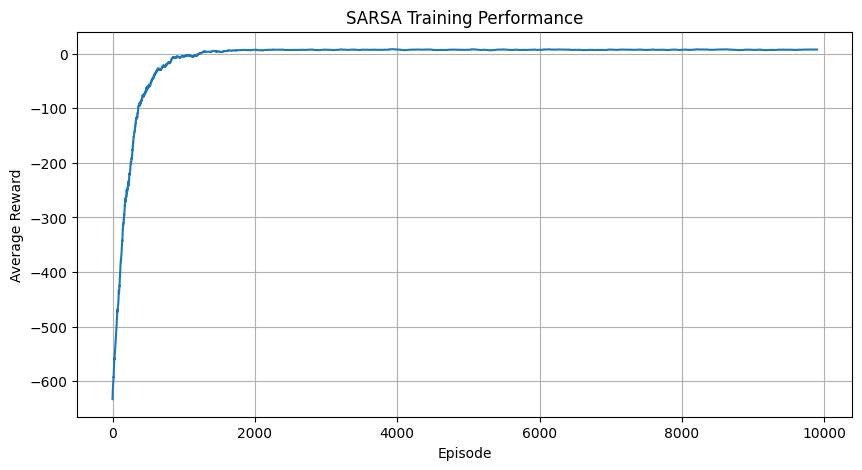

In [10]:
## **Plot SARSA Training Performance**

plt.figure(figsize=(10, 5))

plt.plot(
    moving_average
)

plt.xlabel("Episode")
plt.ylabel("Average Reward")

plt.title(
    "SARSA Training Performance"
)

plt.grid(True)

plt.show()

## **Evaluate Learned Policy**

In [11]:
## **Evaluate Learned Policy**

n_eval_episodes = 1000

evaluation_rewards = []
evaluation_steps = []

for episode in range(n_eval_episodes):

    state, info = env.reset()

    total_reward = 0
    steps = 0

    terminated = False
    truncated = False

    while not (terminated or truncated):

        # Greedy action selection
        action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, info = env.step(action)

        total_reward += reward
        steps += 1

        state = next_state

    evaluation_rewards.append(total_reward)
    evaluation_steps.append(steps)

print("========== EVALUATION RESULTS ==========")

print(
    "Average Reward:",
    round(np.mean(evaluation_rewards), 3)
)

print(
    "Average Steps:",
    round(np.mean(evaluation_steps), 2)
)

print(
    "Successful Episodes:",
    sum(
        reward > 0
        for reward in evaluation_rewards
    )
)

print(
    "Success Rate:",
    round(
        sum(reward > 0 for reward in evaluation_rewards)
        / n_eval_episodes * 100,
        2
    ),
    "%"
)

========== EVALUATION RESULTS ==========
Average Reward: 7.953
Average Steps: 13.05
Successful Episodes: 1000
Success Rate: 100.0 %


## **Display Sample Q-Values**

In [12]:
## **Display Sample Q-Values**

print("========== SAMPLE Q-TABLE VALUES ==========")

for state in range(10):

    best_action = np.argmax(Q[state])

    print(
        f"State {state}: "
        f"Q-values = {np.round(Q[state], 2)} | "
        f"Best Action = {best_action}"
    )

========== SAMPLE Q-TABLE VALUES ==========
State 0: Q-values = [0. 0. 0. 0. 0. 0.] | Best Action = 0
State 1: Q-values = [ -3.26  -2.51  -3.33  -5.08   8.52 -10.67] | Best Action = 4
State 2: Q-values = [ -2.22  -5.57  -3.52   0.68  13.03 -11.25] | Best Action = 4
State 3: Q-values = [-5.17 -1.38 -4.12 -0.54 10.32 -8.87] | Best Action = 4
State 4: Q-values = [ -9.5   -9.52  -3.52  -9.57 -10.2  -11.13] | Best Action = 2
State 5: Q-values = [0. 0. 0. 0. 0. 0.] | Best Action = 0
State 6: Q-values = [ -4.7  -10.65 -10.6  -10.62 -12.54 -10.94] | Best Action = 0
State 7: Q-values = [-6.9  -7.05 -1.29 -6.99 -7.01 -7.87] | Best Action = 2
State 8: Q-values = [  6.13  -6.85  -6.75  -6.72 -11.79 -12.27] | Best Action = 0
State 9: Q-values = [ 3.63 -7.69 -7.6  -7.62 -9.21 -7.76] | Best Action = 0


## **Compare Training and Evaluation Performance**

In [13]:
## **Compare Training and Evaluation Performance**

print("========== PERFORMANCE SUMMARY ==========")

print(
    "Training Average Reward:",
    round(np.mean(episode_rewards[-1000:]), 3)
)

print(
    "Evaluation Average Reward:",
    round(np.mean(evaluation_rewards), 3)
)

print(
    "Evaluation Average Steps:",
    round(np.mean(evaluation_steps), 2)
)

========== PERFORMANCE SUMMARY ==========
Training Average Reward: 7.452
Evaluation Average Reward: 7.953
Evaluation Average Steps: 13.05


## **Observation**

1. The Taxi-v3 environment was successfully created.

2. A Q-table containing state-action values was initialized.

3. The SARSA algorithm learned through interaction with the environment.

4. An ε-greedy strategy was used to balance exploration and exploitation.

5. The Q-table was updated after every state-action transition.

6. SARSA uses the action actually selected by the current policy for
   calculating the next-state value.

7. As training progressed, the agent learned better routes for completing
   the taxi task.

8. During evaluation, the learned policy was executed without exploration.

9. The trained agent generally required fewer steps and obtained better
   rewards than during the early stages of training.

## **Conclusion**

The SARSA algorithm was successfully implemented on the Taxi-v3 environment.

The agent learned an action-value function through on-policy Temporal Difference learning.

The ε-greedy strategy allowed the agent to explore different actions while gradually learning an effective policy.

The experiment demonstrated that SARSA can learn a policy for solving a standard Reinforcement Learning environment through repeated interaction.